In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# Load saved data from Notebook 2
with open('data/train_test_data.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

with open('data/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("✅ Data loaded successfully!")
print("   X_train shape:", X_train.shape)
print("   X_test  shape:", X_test.shape)

✅ Data loaded successfully!
   X_train shape: (299, 10)
   X_test  shape: (75, 10)


In [2]:
print("Training Logistic Regression...")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print("✅ Logistic Regression trained!")
print(f"   Accuracy: {lr_acc:.2%}")

Training Logistic Regression...
✅ Logistic Regression trained!
   Accuracy: 98.67%


In [3]:
print("=== Detailed Report — Logistic Regression ===\n")
print(classification_report(y_test, lr_pred,
      target_names=['High', 'Low', 'Medium']))

=== Detailed Report — Logistic Regression ===

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        30
         Low       1.00      0.97      0.99        40
      Medium       0.83      1.00      0.91         5

    accuracy                           0.99        75
   macro avg       0.94      0.99      0.97        75
weighted avg       0.99      0.99      0.99        75



In [4]:
print("Training Decision Tree...")

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print("✅ Decision Tree trained!")
print(f"   Accuracy: {dt_acc:.2%}")

Training Decision Tree...
✅ Decision Tree trained!
   Accuracy: 96.00%


In [5]:
print("=== Detailed Report — Decision Tree ===\n")
print(classification_report(y_test, dt_pred,
      target_names=['High', 'Low', 'Medium']))

=== Detailed Report — Decision Tree ===

              precision    recall  f1-score   support

        High       1.00      0.97      0.98        30
         Low       1.00      0.95      0.97        40
      Medium       0.62      1.00      0.77         5

    accuracy                           0.96        75
   macro avg       0.88      0.97      0.91        75
weighted avg       0.97      0.96      0.96        75



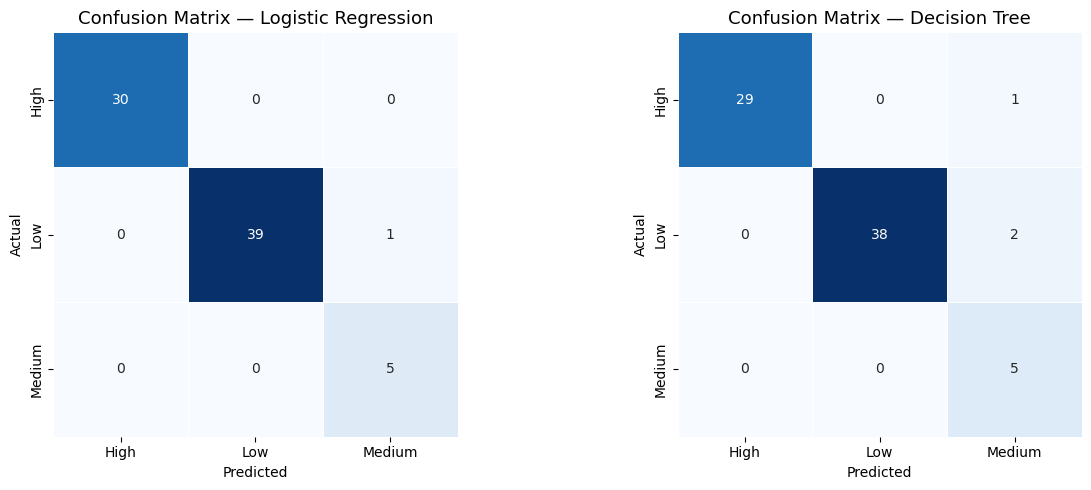

✅ Saved confusion_matrices.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ['High', 'Low', 'Medium']

for ax, pred, name in zip(
    axes,
    [lr_pred, dt_pred],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5, square=True, cbar=False)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=13)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("visuals/confusion_matrices.png")
plt.show()
print("✅ Saved confusion_matrices.png")

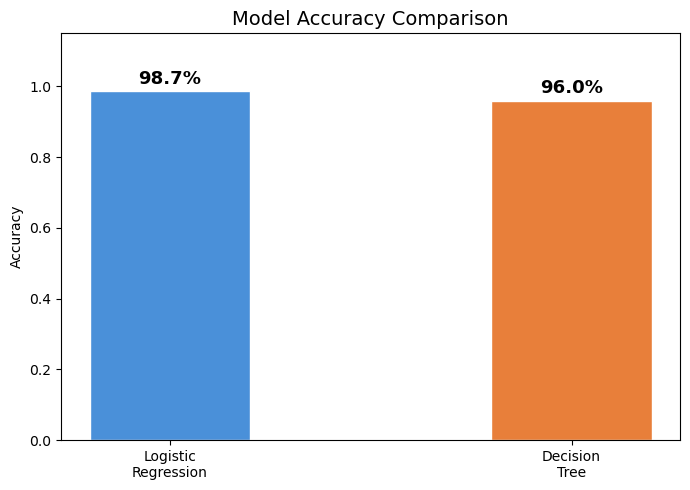

✅ Saved accuracy_comparison.png

   Winner: Logistic Regression


In [7]:
models = ['Logistic\nRegression', 'Decision\nTree']
accs   = [lr_acc, dt_acc]
colors = ['#4A90D9', '#E87F3A']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accs, color=colors, edgecolor='white', width=0.4)
plt.ylim(0, 1.15)
plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy")

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{acc:.1%}", ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("visuals/accuracy_comparison.png")
plt.show()
print(f"✅ Saved accuracy_comparison.png")
print(f"\n   Winner: {'Logistic Regression' if lr_acc > dt_acc else 'Decision Tree'}")

In [9]:
print("Running 5-fold cross validation...")

lr_cv = cross_val_score(lr, X_train, y_train, cv=5, scoring='accuracy')
dt_cv = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')

print("\n=== Cross Validation Results ===")
print(f"\nLogistic Regression:")
print(f"   Scores : {[f'{s:.2%}' for s in lr_cv]}")
print(f"   Average: {lr_cv.mean():.2%}")

print(f"\nDecision Tree:")
print(f"   Scores : {[f'{s:.2%}' for s in dt_cv]}")
print(f"   Average: {dt_cv.mean():.2%}")

Running 5-fold cross validation...

=== Cross Validation Results ===

Logistic Regression:
   Scores : ['93.33%', '93.33%', '98.33%', '95.00%', '98.31%']
   Average: 95.66%

Decision Tree:
   Scores : ['93.33%', '96.67%', '100.00%', '100.00%', '98.31%']
   Average: 97.66%


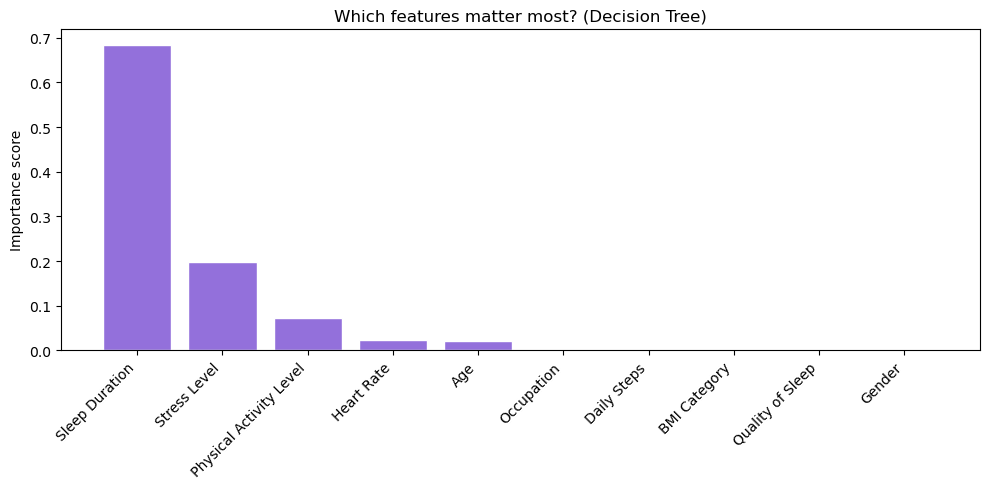

✅ Saved feature_importance.png

Top 3 most important features:
   1. Sleep Duration: 0.685
   2. Stress Level: 0.199
   3. Physical Activity Level: 0.072


In [10]:
importances = dt.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)),
        importances[idx],
        color='mediumpurple', edgecolor='white')
plt.xticks(range(len(importances)),
           [feature_names[i] for i in idx],
           rotation=45, ha='right', fontsize=10)
plt.title("Which features matter most? (Decision Tree)")
plt.ylabel("Importance score")
plt.tight_layout()
plt.savefig("visuals/feature_importance.png")
plt.show()

print("✅ Saved feature_importance.png")
print("\nTop 3 most important features:")
for i in range(3):
    print(f"   {i+1}. {feature_names[idx[i]]}: {importances[idx[i]]:.3f}")

In [11]:
with open('data/model_lr.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('data/model_dt.pkl', 'wb') as f:
    pickle.dump(dt, f)

print("✅ Both models saved!")
print("\n=== FINAL SUMMARY ===")
print(f"   Logistic Regression accuracy : {lr_acc:.2%}")
print(f"   Decision Tree accuracy       : {dt_acc:.2%}")
print(f"   Best model                   : {'Decision Tree' if dt_acc > lr_acc else 'Logistic Regression'}")

✅ Both models saved!

=== FINAL SUMMARY ===
   Logistic Regression accuracy : 98.67%
   Decision Tree accuracy       : 96.00%
   Best model                   : Logistic Regression
